In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import openpyxl as px

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
e1 = pd.read_csv(r"/Users/alejandrabenavidessanclemente/Desktop/ProyectoGradoGEB/datos_procesados.csv")

In [5]:
nulos = e1.isnull().sum()
print(nulos)

duplicados = e1.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

ORIG_STD_VOLUME     0
STD_VOLUME          0
ORIG_TEMPERATURE    0
TEMPERATURE         0
PRESSURE            0
ORIG_PRESSURE       0
ORIG_RAW_VOLUME     0
RAW_VOLUME          0
EFFECTIVE_DATE      0
empresa_EICH101     0
empresa_EICH102     0
empresa_EICH104     0
dtype: int64
Número de filas duplicadas: 0


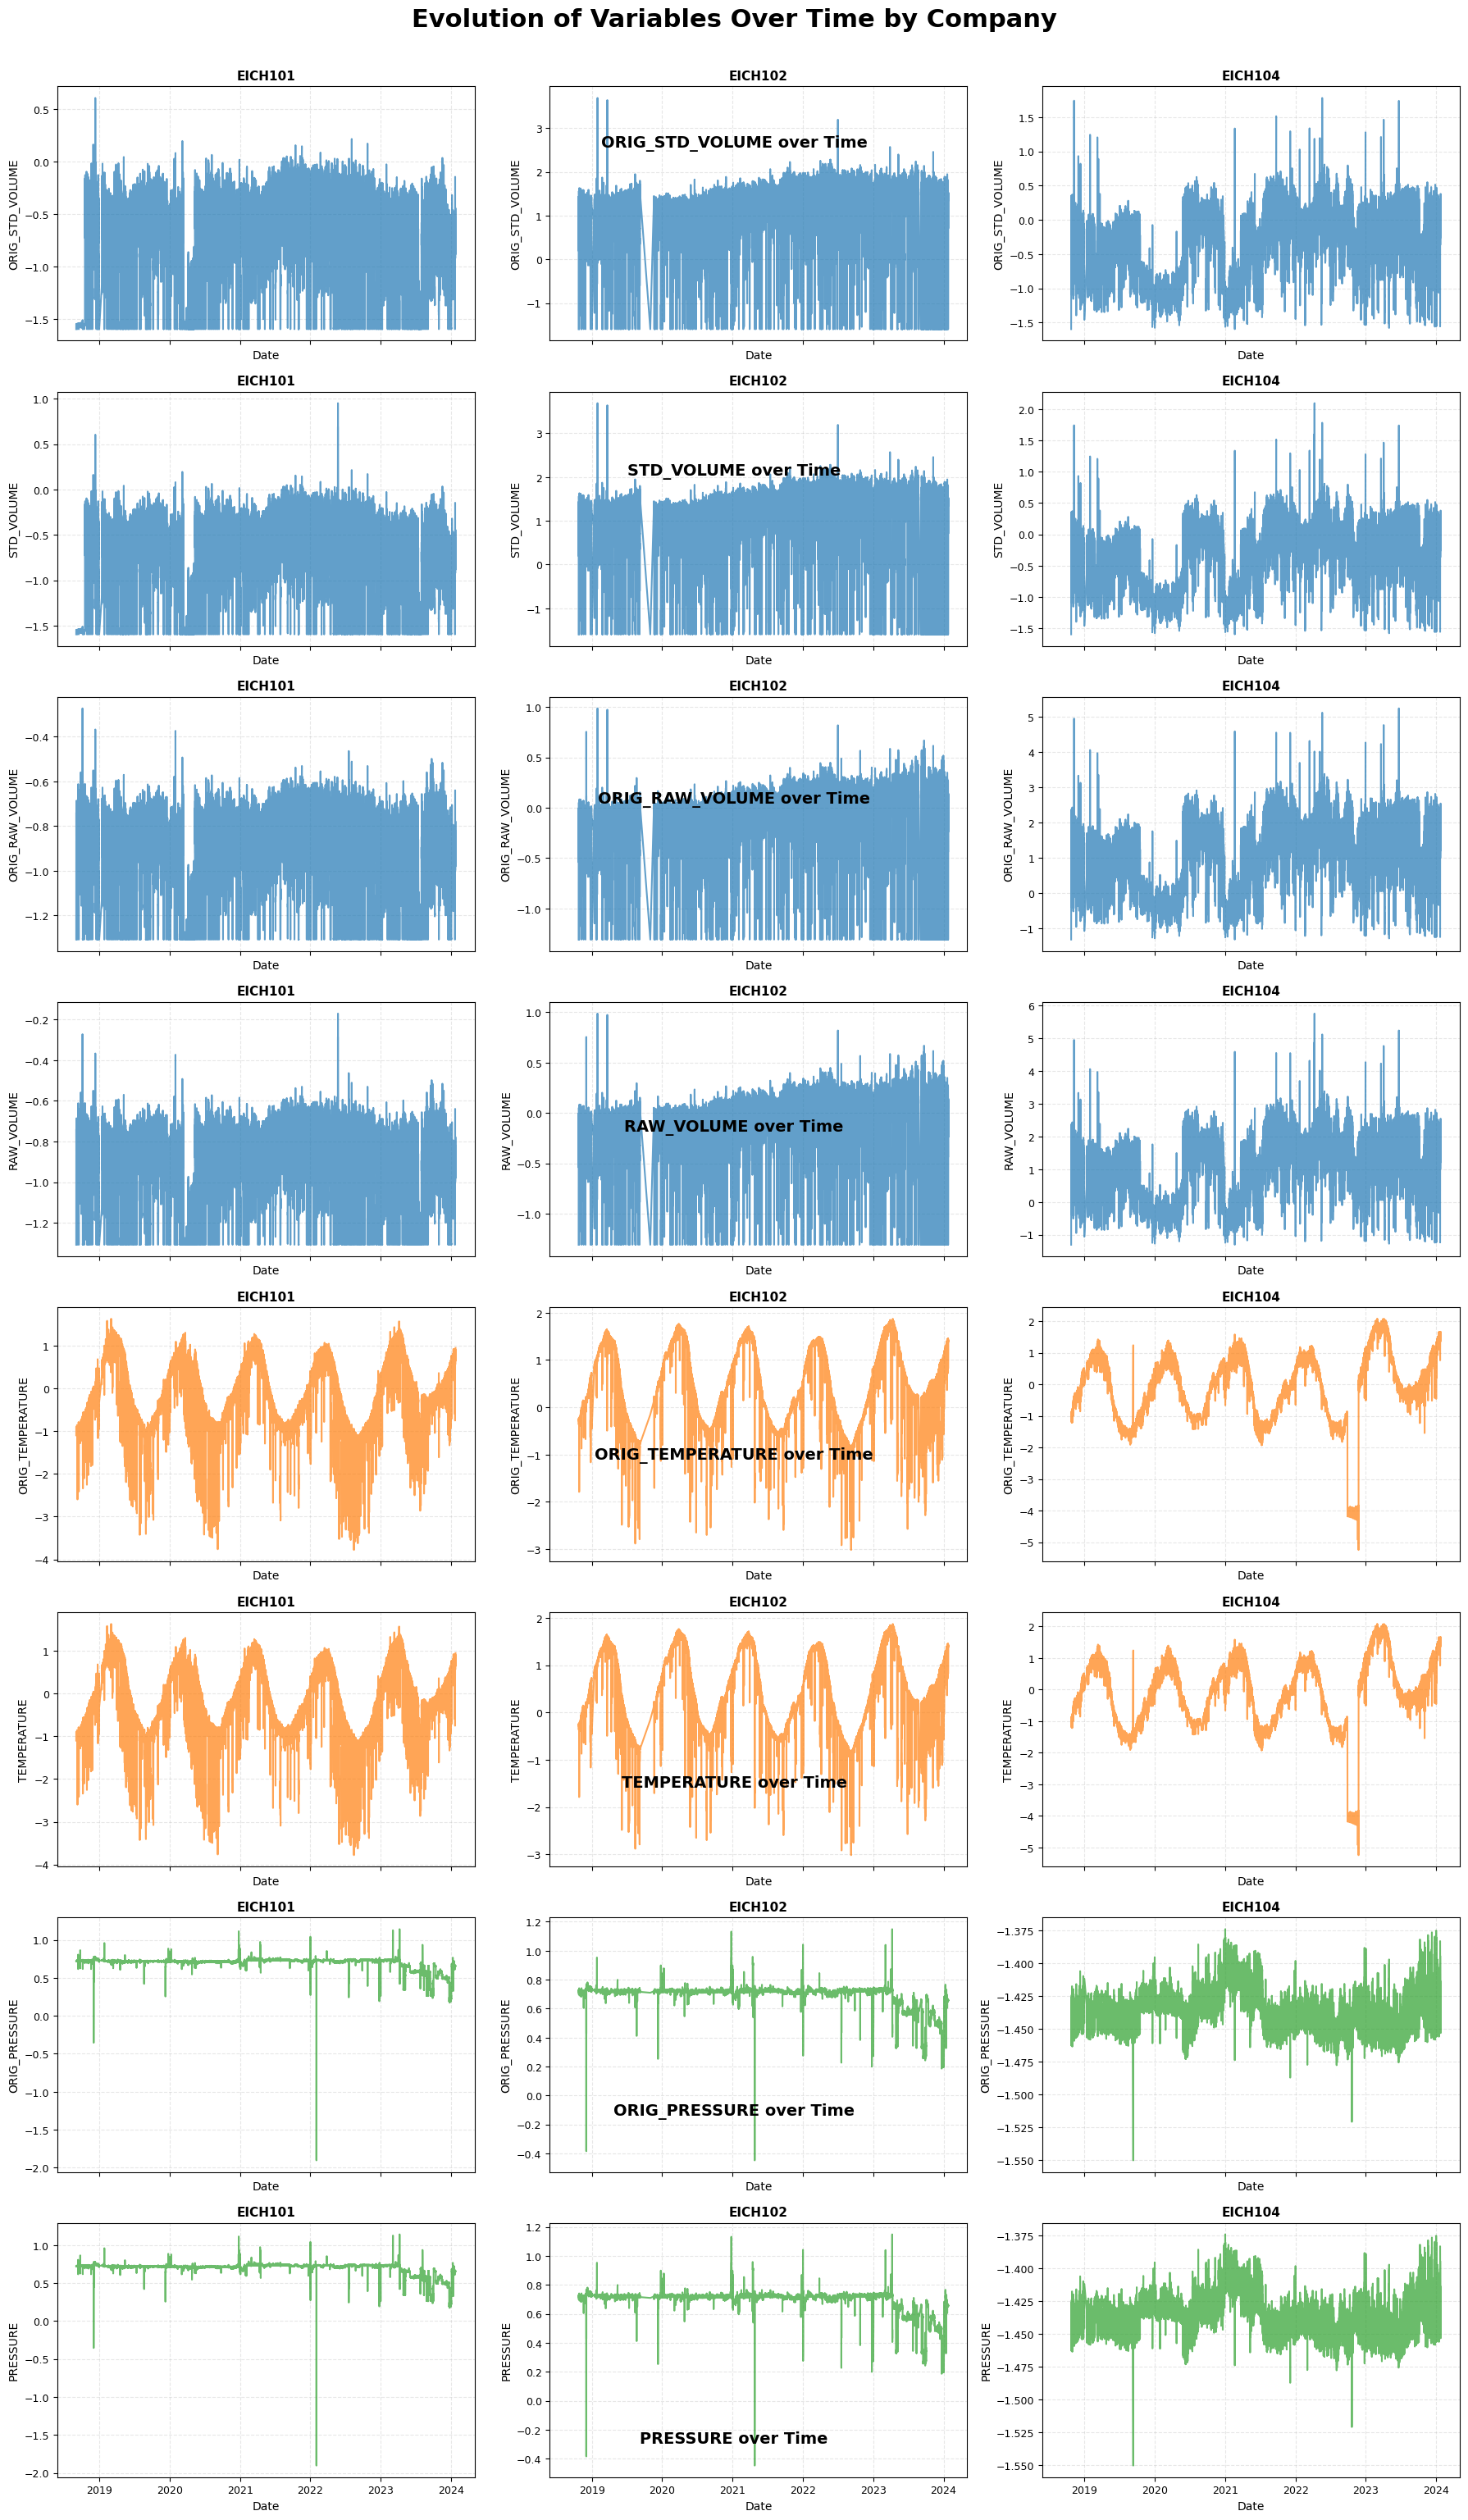

In [36]:
# Crear columna 'COMPANY' a partir del One-Hot Encoding
def identify_company(row):
    for col in ['empresa_EICH101', 'empresa_EICH102', 'empresa_EICH104']:
        if row[col] == 1:
            return col.replace('empresa_', '')
    return 'Unknown'

e1['COMPANY'] = e1.apply(identify_company, axis=1)

# Convertir fechas
e1['EFFECTIVE_DATE'] = pd.to_datetime(e1['EFFECTIVE_DATE'])

# Variables
variable_units = {
    'ORIG_STD_VOLUME',
    'STD_VOLUME',
    'ORIG_RAW_VOLUME',
    'RAW_VOLUME',
    'ORIG_TEMPERATURE',
    'TEMPERATURE',
    'ORIG_PRESSURE',
    'PRESSURE'
}

# Colores por categoría
category_colors = {
    'Volume': '#1f77b4',
    'Temperature': '#ff7f0e',
    'Pressure': '#2ca02c'
}

# Categorías
volume_vars = ['ORIG_STD_VOLUME', 'STD_VOLUME', 'ORIG_RAW_VOLUME', 'RAW_VOLUME']
temperature_vars = ['ORIG_TEMPERATURE', 'TEMPERATURE']
pressure_vars = ['ORIG_PRESSURE', 'PRESSURE']
variables = volume_vars + temperature_vars + pressure_vars

# Empresas
companies = e1['COMPANY'].unique()

# Crear figura
fig, axs = plt.subplots(len(variables), len(companies), figsize=(18, 4 * len(variables)), sharex=True)

# Asegurar que axs sea 2D
if len(companies) == 1:
    axs = axs.reshape(-1, 1)

# Graficar
for row_idx, var in enumerate(variables):
    if var in volume_vars:
        color = category_colors['Volume']
    elif var in temperature_vars:
        color = category_colors['Temperature']
    else:
        color = category_colors['Pressure']
    
    # Título centrado sobre la fila (nombre exacto de la variable)
    fig.text(0.5, 1 - (row_idx + 0.5) / len(variables), f"{var} over Time",
             ha='center', va='center', fontsize=14, fontweight='bold')

    for col_idx, company in enumerate(companies):
        ax = axs[row_idx][col_idx]
        df_company = e1[e1['COMPANY'] == company]
        
        ax.plot(df_company['EFFECTIVE_DATE'], df_company[var], color=color, alpha=0.7)
        
        ax.set_ylabel(f"{var}", fontsize=10)
        ax.set_xlabel("Date", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_title(company, fontsize=11, fontweight='bold')
        ax.tick_params(labelsize=9)

# Ajustar diseño
plt.tight_layout(rect=[0,0.03, 1, 0.97])
plt.suptitle("Evolution of Variables Over Time by Company", fontsize=22, fontweight='bold', y=0.989)
plt.subplots_adjust(hspace=0.2, wspace=0.18)
plt.show()